<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html hw4.do.txt --no_mako -->
<!-- dom:TITLE: PHY321: Classical Mechanics 1 -->

## Exercise 5 (40pt), Bouncing object

This exercise builds on the code you wrote for solving homework 3.
We recommend strongly that you study the text of Malthe-Sørenssen, section 7.5.

In homework 3 we introduced gravity and air resistance and studied their
effects via a constant acceleration due to gravity and the force
arising from air resistance. But what happens when the ball hits the
floor? What if we would like to simulate the normal force from the
floor acting on the ball?  This exercise shows how we can include more
complicated forces with no pain! And the force we include here is an
example of a case where analytical solutions may either be difficult
to find or we cannot find an analytical solution at all.

We need then to include a force model for the normal force from the
floor on the ball. The simplest approach to such a system is to
introduce a contact force model represented by a spring model.  We
model the interaction between the floor and the ball as a single
spring. But the normal force is zero when there is no contact. Here we
define a simple model that allows us to include such effects in our
models.

The normal force from the floor on the ball is represented by a spring force. This
is a strong simplification of the actual deformation process occurring at the contact
between the ball and the floor due to the deformation of both the ball and the floor.

The deformed region corresponds roughly to the region of **overlap** between the
ball and the floor. The depth of this region is $\Delta y = R − y(t)$, where $R$
is the radius of the ball. This is supposed to represent the compression of the spring.
Our model for the normal force acting on the ball is then

$$
\boldsymbol{N} = −k (R − y(t)) \boldsymbol{e}_y.
$$

The normal force must act upward when $y < R$,
hence the sign must be negative.
However, we must also ensure that the normal force only acts when the ball is in
contact with the floor, otherwise the normal force is zero. The full formation of the
normal force is therefore

$$
\boldsymbol{N} = −k (R − y(t)) \boldsymbol{e}_y,
$$

when $y(t) < R$ and zero when $y(t) \ge R$.
In the numerical calculations you can choose $R=0.1$ m and the spring constant $k=1000$ N/m.

* 5a (10pt) Identify the forces acting on the ball and set up a diagram with the forces acting on the ball. Find the acceleration of the falling ball now with the normal force as well.

* 5b (10pt) Starting from the code that you write for HW3 Exercise 7 (or the posted solution), add the necessary lines of code to setup and compute these new forces (i.e., the normal interaction). What kind of [control structure](https://en.wikipedia.org/wiki/Control_flow) (e.g., `if`, `try`, `switch`) is helpful here? Write a short summary of your changes either as a comment or a separate cell. Make sure you explain the new calculations.

* 5c (10pt) Update the code to include a plot of the ball's height over time (i.e., $y$ vs $t$). How can you tell that the plot makes sense? What should we be looking for and how do you see those features in your plot? Again, write a short summary of your changes either as a comment or a separate cell. Make sure you explain the new calculations.

* 5d (10pt) Using different starting (initial) conditions (i.e., $v_0$, $y_0$) for the same choice of time step ($\Delta t$), when does your model break down? How can you tell? For reasonable values of $v_0$ and $y_0$ like in a physics lab, at what $\Delta t$ does your model break down? Again, how can you tell? What do these investigations indicate is important about choosing the integration time step ($\Delta t$) when modeling classical systems?

5b: The If control structure was usefull here, I used it to check if the position of the ball is in the ground. The primary changes I made to the code were a change to the accaleration function to make it dependent on the position of the ball and adjusted to include the spring force and changes to the imtegration loop to include the y position as that is now a variable that affects the accaleration. 

In [61]:
import numpy as np
import matplotlib.pyplot as plt

#initial values
m = 0.2          # mass [kg]
g = 9.81         # gravity [m/s^2]
D = 8.0e-3       # drag coefficient
R = 0.1          # ball radius [m]
k = 1000         # spring constant [N/m]

y0 = 2.0         # initial height [m]
v0 = 0.0         # initial velocity [m/s]
t0 = 0.0
t_final = 3.0    # total simulation time


def acceleration(y, v):
    # accaleration in the air accounts for gravity and deag with drag opposing velocity.
    a = -g - (D/m) * v*abs(v)

    # check if in the ground and adjust accaleration if true
    if y < R:
        a += (k/m) * (R - y) ## standard spring force equation for accaleration adjusted to take the radius of teh ball into account

    return a


def euler(dt):
    N = int((t_final - t0) / dt)

    t = np.zeros(N)
    y = np.zeros(N)
    v = np.zeros(N)
    a = np.zeros(N)

    # Initial values
    t[0] = t0
    y[0] = y0
    v[0] = v0
    a[0] = acceleration(y[0], v[0])

    # Time integration loop: Changed to include y
    for i in range(N - 1):
        v[i+1] = v[i] + dt * a[i]
        y[i+1] = y[i] + dt * v[i]
        a[i+1] = acceleration(y[i+1], v[i+1])
        t[i+1] = t[i] + dt

    return t, y, v



5c: The code seems to function as well. While there is a small increase in amplitude over time this can be attribuited to usinng eulers method whcih often overcounts velocity. I can tell that the code seems to be working as expected as expected by observing the behavior of the ball. It starts at the expected height falls sinks slightly into the floor then bounces up to a lower height than it was dropped from due to the drag leeching off energy. 

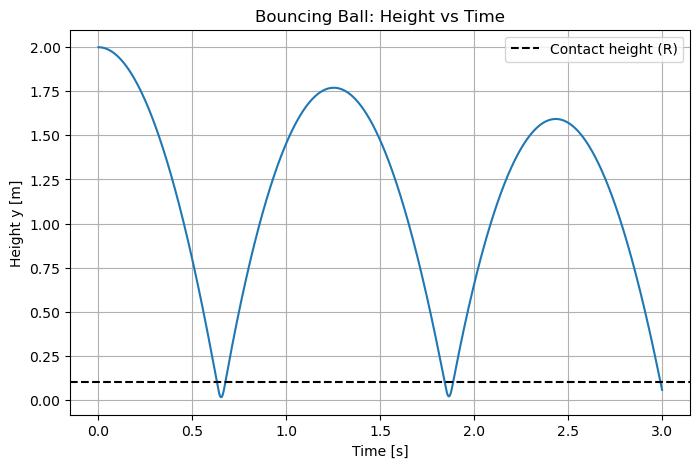

In [62]:
dt = 0.0001 #setting time step

##standard graphing code for height
plt.figure(figsize=(8,5))

t_num, y_num, v_num = euler(dt)
plt.plot(t_num, y_num)

plt.axhline(R, color='k', linestyle='--', label="Contact height (R)")
plt.xlabel("Time [s]")
plt.ylabel("Height y [m]")
plt.title("Bouncing Ball: Height vs Time")
plt.legend()
plt.grid()
plt.show()


5d: my model handles High initial heights(y0) effectively as the included drag causes a terminal velocity, however it handles high initial velocities(v0) poorly as it assums that the floor is a ideal spring, something clearly illogical. In the tested example below this leads to teh ball sinking almost 40 meters into the ground. This model also breakes down with sufficilently large dt. ie dt>0.0005, as the overcounting of velocity from the euler method leads to the ball bouncing higher that it ws initally dropped from, a graph showing this can be seen below. This graph was tested ith no inital velocity and a ball dropped form a height of 2m, these inital values are resonable for any ball dropping physics lab withough special equiptment to launch the ball at a specific velocity. 

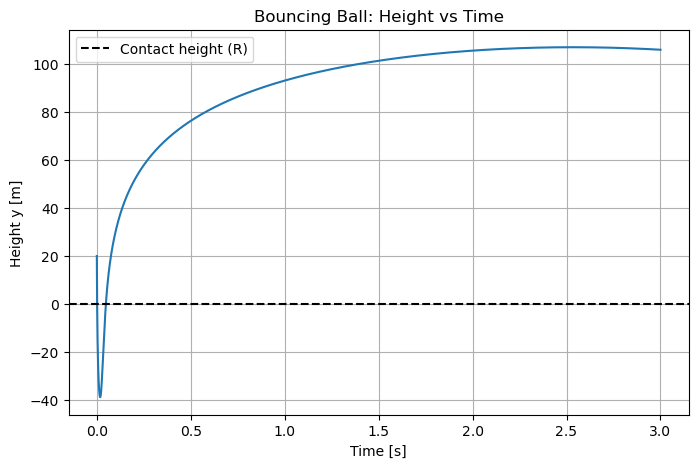

In [63]:


#initial values
m = 0.2          # mass [kg]
g = 9.81         # gravity [m/s^2]
D = 8.0e-3       # drag coefficient
R = 0.1          # ball radius [m]
k = 1000         # spring constant [N/m]

y0 = 20.0         # initial height [m]
v0 = -20000.0         # initial velocity [m/s]
t0 = 0.0
t_final = 3.0    # total simulation time


def acceleration(y, v):
    # accaleration in the air accounts for gravity and deag with drag opposing velocity.
    a = -g - (D/m) * v*abs(v)

    # check if in the ground and adjust accaleration if true
    if y < R:
        a += (k/m) * (R - y) ## standard spring force equation for accaleration adjusted to take the radius of teh ball into account

    return a


def euler(dt):
    N = int((t_final - t0) / dt)

    t = np.zeros(N)
    y = np.zeros(N)
    v = np.zeros(N)
    a = np.zeros(N)

    # Initial values
    t[0] = t0
    y[0] = y0
    v[0] = v0
    a[0] = acceleration(y[0], v[0])

    # Time integration loop: Changed to include y
    for i in range(N - 1):
        v[i+1] = v[i] + dt * a[i]
        y[i+1] = y[i] + dt * v[i]
        a[i+1] = acceleration(y[i+1], v[i+1])
        t[i+1] = t[i] + dt

    return t, y, v


plt.figure(figsize=(8,5))


t_num, y_num, v_num = euler(dt)
plt.plot(t_num, y_num)

plt.axhline(R, color='k', linestyle='--', label="Contact height (R)")
plt.xlabel("Time [s]")
plt.ylabel("Height y [m]")
plt.title("Bouncing Ball: Height vs Time")
plt.legend()
plt.grid()
plt.show()

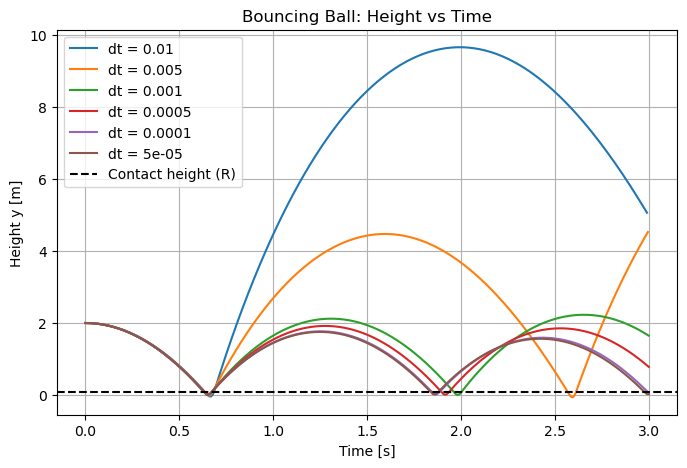

In [64]:
#testing different dt values with origional initial conditions 

dt_lst = [0.01,0.005,0.001,0.0005,0.0001,0.00005]
m = 0.2          # mass [kg]
g = 9.81         # gravity [m/s^2]
D = 8.0e-3       # drag coefficient
R = 0.1          # ball radius [m]
k = 1000         # spring constant [N/m]

y0 = 2.0         # initial height [m]
v0 = 0.0         # initial velocity [m/s]
t0 = 0.0
t_final = 3.0    # total simulation time

plt.figure(figsize=(8,5))

for dtl in dt_lst:
    t_num, y_num, v_num = euler(dtl)
    plt.plot(t_num, y_num, label=f"dt = {dtl}")

plt.axhline(R, color='k', linestyle='--', label="Contact height (R)")
plt.xlabel("Time [s]")
plt.ylabel("Height y [m]")
plt.title("Bouncing Ball: Height vs Time")
plt.legend()
plt.grid()
plt.show()